In [1]:
# Uncomment these in a fresh notebook environment.
#%pip install -r ../requirements.txt
#%pip install -e ..

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt

GREEN_PHASE_COUNT = 4

def print_comparison_table(rows):
    columns = [
        "Policy",
        "Episodes",
        "Mean total reward",
        "Mean local queue",
        "Total completed steps",
        "Mean switches / episode",
    ]

    def format_value(value):
        if isinstance(value, float):
            return f"{value:.3f}"
        return str(value)

    widths = {column: len(column) for column in columns}
    for row in rows:
        for column in columns:
            widths[column] = max(widths[column], len(format_value(row.get(column, ""))))

    header = " | ".join(column.ljust(widths[column]) for column in columns)
    separator = "-+-".join("-" * widths[column] for column in columns)
    print(header)
    print(separator)
    for row in rows:
        print(" | ".join(format_value(row.get(column, "")).ljust(widths[column]) for column in columns))


In [3]:
from marl_tsc.simulation_generator import SimulationGenerator, DEFAULT_TRAFFIC_LIGHT_IDS
from marl_tsc.training import train_ppo, evaluate_policy, plot_training_histories
from marl_tsc.mappo import train_mappo
from marl_tsc.baselines import random_actions, fixed_time_actions

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "main_flow.ipynb").exists() else NOTEBOOK_DIR
OUTPUT_DIR = PROJECT_ROOT / "outputs"

traffic_light_ids = list(DEFAULT_TRAFFIC_LIGHT_IDS)


## 1. Generate the SUMO simulation files

This default setup is a small `4x4` grid with four traffic-light agents. Change these values first when you want a different learning problem.


In [4]:
# ==========================================
# MASTER VARIABLE: Controls the entire run
# ==========================================
EPISODE_STEPS = 400_000  # The number of actions/steps the RL agent takes per episode


# ==========================================
# Derived Parameters
# ==========================================
SECONDS_PER_ACTION = 5  # Matches the step logic in your SumoTrafficEnv
# The actual duration in SUMO seconds that the RL agent will experience
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION  # 3000 SUMO seconds

# To ensure continuous flow, spawn vehicles for 20% longer than the simulation runs.
# This guarantees that the network never empties out or hits ACT = 0.
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)  # 3600 SUMO seconds

NUM_EPISODES = 30
EVALUATION_EPISODES = 10
TOTAL_TIMESTEPS = SIMULATION_DURATION
MIN_GREEN_SECONDS = 10


# ==========================================
# Generator Configuration
# ==========================================
generator = SimulationGenerator(
    output_dir=OUTPUT_DIR,
    grid_number=4,
    lane_number=2,
    traffic_light_ids=traffic_light_ids,
    trip_begin=0,
    trip_end=TRAFFIC_SPAWN_DURATION,  # Extends past the simulation end!
    trip_period=2,                    # Steady stream: 1 car every 2 seconds
    seed=42,
)

paths = generator.generate_all()
print(f"Generated continuous flow configuration: {paths.config_file}")
print(f"Simulation Horizon: {SIMULATION_DURATION}s | Traffic Spawning Until: {TRAFFIC_SPAWN_DURATION}s")
print("Traffic-light agents:", traffic_light_ids)


Success.
calling /usr/share/sumo/bin/duarouter -n /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/network.net.xml -r /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/trips.trips.xml --ignore-errors --begin 0 --end 2400000 --no-step-log --no-warnings -o /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/routes.rou.xml
Success.
Generated continuous flow configuration: /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/config.sumocfg
Simulation Horizon: 2000000s | Traffic Spawning Until: 2400000s
Traffic-light agents: ['B1', 'B2', 'C1', 'C2']


## 2. Run the simple baselines

Random and fixed-time are useful sanity checks before training. They use the same environment and the same evaluation seeds as the learned policies.


In [5]:
# ==========================================
# 1. RANDOM BASELINE EVALUATION
# ==========================================
random_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,             # Match MAPPO: TODO:Extract dynamically from the net file
    policy=random_actions,
    episodes=1,#EVALUATION_EPISODES,       # Use 10 episodes to match MAPPO evaluation
    max_steps=600, #EPISODE_STEPS,            # FIX: Must be 600 steps, not 3000 duration
    seed=42,
    env_kwargs={
        "green_phase_count": 4,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        #"max_steps": 600,     # Pass to ensure internal alignment
    },
)

# ==========================================
# 2. FIXED-TIME BASELINE EVALUATION
# ==========================================
fixed_time_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,             # Match MAPPO: TODO: Extract dynamically from the net file
    policy=fixed_time_actions,
    episodes= 1,#EVALUATION_EPISODES,       # Use 10 episodes to match MAPPO evaluation
    max_steps= 600, #EPISODE_STEPS,            # FIX: Must be 600 steps, not 3000 duration
    seed=42,
    env_kwargs={
        "green_phase_count": 4,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        #"max_steps": 600,     # Pass to ensure internal alignment
    },
)

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 2ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #3000.00 (0ms ?*RT. ?UPS, TraCI: 7ms, vehicles TOT 1500 ACT 39 BUF 0)                
Finished Evaluation Episode 1/1 - Total Reward: -133.12
 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 2ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #3000.00 (3ms ~= 333.33*RT, ~184000.00UPS, TraCI: 8ms, vehicles TOT 1160 ACT 552 BUF 
Finished Evaluation Episode 1/1 - Total Reward: -1335.24


In [6]:
baseline_rows = [
    {
        "Policy": "Random",
        "Episodes": random_result["episodes"],
        "Mean total reward": random_result["mean_total_reward"],
        "Mean local queue": random_result["mean_local_queue"],
        "Total completed steps": random_result["total_completed_steps"],
        "Mean switches / episode": random_result["mean_switches_per_episode"],
    },
    {
        "Policy": "Fixed-Time",
        "Episodes": fixed_time_result["episodes"],
        "Mean total reward": fixed_time_result["mean_total_reward"],
        "Mean local queue": fixed_time_result["mean_local_queue"],
        "Total completed steps": fixed_time_result["total_completed_steps"],
        "Mean switches / episode": fixed_time_result["mean_switches_per_episode"],
    },
]
print_comparison_table(baseline_rows)

Policy     | Episodes | Mean total reward | Mean local queue | Total completed steps | Mean switches / episode
-----------+----------+-------------------+------------------+-----------------------+------------------------
Random     | 1        | -133.120          | 0.512            | 600                   | 1027.000               
Fixed-Time | 1        | -1335.235         | 5.514            | 600                   | 1196.000               


## 3. Train

PPO uses parameter sharing through the PettingZoo/SuperSuit/SB3 wrapper. MAPPO adds a centralized critic and a shared decentralized actor.


### PPO

In [7]:
ppo_model, ppo_history, ppo_model_path = train_ppo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    max_steps=SIMULATION_DURATION,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT,
                "min_green_seconds": MIN_GREEN_SECONDS },
)

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 1ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 2856ms, vehicles TOT 0 ACT 0 BUF 0)                   
 Retrying in 1 seconds
Step #2400080.00 (0ms ?*RT. ?UPS, TraCI: 5ms, vehicles TOT 1200000 ACT 0 BUF 0)           tep #4500.00 (0ms ?*RT. ?UPS, TraCI: 10ms, vehicles TOT 2251 ACT 36 BUF 0)               ep #9000.00 (0ms ?*RT. ?UPS, TraCI: 11ms, vehicles TOT 4500 ACT 40 BUF 1)               p #13500.00 (0ms ?*RT. ?UPS, TraCI: 32ms, vehicles TOT 6751 ACT 33 BUF 0)               #18000.00 (1ms ~= 1000.00*RT, ~35000.00UPS, TraCI: 10ms, vehicles TOT 9001 ACT 35 BUF#22500.00 (0ms ?*RT. ?UPS, TraCI: 11ms, vehicles TOT 11250 ACT 32 BUF 1)             27000.00 (1ms ~= 1000.00*RT, ~42000.00UPS, TraCI: 10ms, vehicles TOT 13500 ACT 42 BU1500.00 (0ms ?*RT. ?UPS, TraCI: 10ms, vehicles TOT 15751 ACT 46 BUF 0)             000.00 (1ms ~= 1000.00*RT, ~37000.00UPS, TraCI: 14ms, vehic

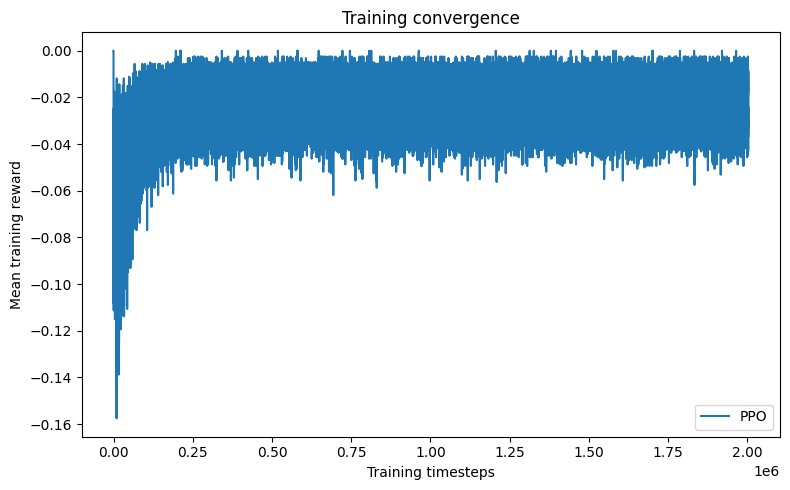

Saved PPO model: /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/ppo_sumo_traffic.zip


In [8]:

fig, ax = plot_training_histories(ppo_history)
plt.show()

print("Saved PPO model:", ppo_model_path)

### MAPPO

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 1ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #2399000.00 (1ms ~= 1000.00*RT, ~31000.00UPS, TraCI: 6ms, vehicles TOT 111)          tep #4500.00 (1ms ~= 1000.00*RT, ~49000.00UPS, TraCI: 7ms, vehicles TOT 2251 ACT 49 BUF 0ep #9000.00 (1ms ~= 1000.00*RT, ~37000.00UPS, TraCI: 8ms, vehicles TOT 4500 ACT 37 BUF 1p #13500.00 (1ms ~= 1000.00*RT, ~39000.00UPS, TraCI: 8ms, vehicles TOT 6750 ACT 39 BUF  #18000.00 (0ms ?*RT. ?UPS, TraCI: 7ms, vehicles TOT 9001 ACT 37 BUF 0)               #22500.00 (1ms ~= 1000.00*RT, ~35000.00UPS, TraCI: 7ms, vehicles TOT 11250 ACT 35 BUF27000.00 (0ms ?*RT. ?UPS, TraCI: 8ms, vehicles TOT 13500 ACT 39 BUF 1)              1500.00 (0ms ?*RT. ?UPS, TraCI: 8ms, vehicles TOT 15751 ACT 44 BUF 0)              000.00 (1ms ~= 1000.00*RT, ~38000.00UPS, TraCI: 7ms, vehicles TOT 18001 ACT 38 BUF00.00 (0ms ?*RT. ?UPS, TraCI: 7ms, vehicles TOT 20250 ACT 40 BUF 1)              0.00 (1ms

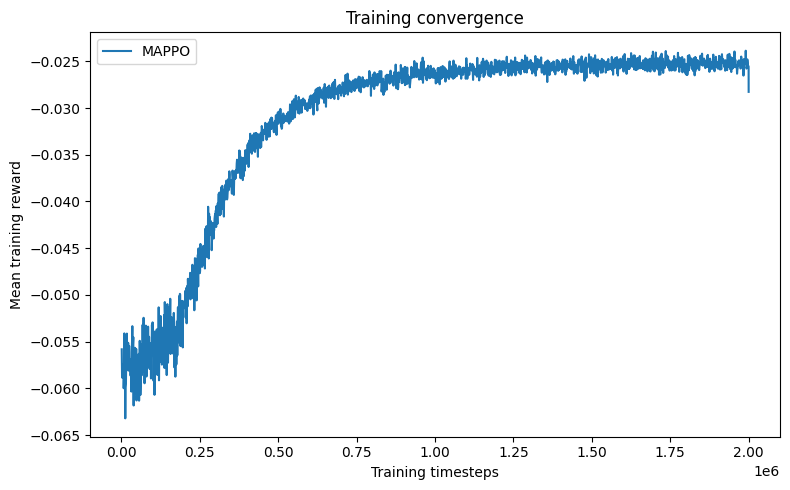

Saved MAPPO model: /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/models/mappo.pt


In [9]:
mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=1024,
    max_steps=SIMULATION_DURATION,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT,
                "min_green_seconds": MIN_GREEN_SECONDS },
)

fig, ax = plot_training_histories(mappo_history)
plt.show()

print("Saved MAPPO model:", mappo_model_path)

## 4. Evaluate all policies on the same seeds

The final comparison table keeps the baseline runs and adds the shared PPO and MAPPO policies on the same evaluation seeds.


In [11]:
shared_mappo_result = evaluate_policy(
    config_file=paths.config_file,
    # 1. Pass None to dynamically extract the agents from the network file, matching training!
    traffic_light_ids=traffic_light_ids, 
    policy=mappo_model,
    episodes=1, #EVALUATION_EPISODES,
    # 2. FIX: Must be EPISODE_STEPS, not SIMULATION_DURATION
    max_steps=EPISODE_STEPS, 
    seed=42, 
    # 3. Pass every environment hyperparameter to ensure observation spaces align perfectly
    env_kwargs={
        "green_phase_count": 4,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        #"max_steps": EPISODE_STEPS,
    },
)

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 2ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #2000000.00 (0ms ?*RT. ?UPS, TraCI: 10ms, vehicles TOT 1000000 ACT 30 BUF 0)         tep #4500.00 (1ms ~= 1000.00*RT, ~26000.00UPS, TraCI: 6ms, vehicles TOT 2251 ACT 26 BUF 0ep #9000.00 (0ms ?*RT. ?UPS, TraCI: 8ms, vehicles TOT 4500 ACT 26 BUF 1)                p #13500.00 (0ms ?*RT. ?UPS, TraCI: 8ms, vehicles TOT 6751 ACT 23 BUF 0)                #18000.00 (0ms ?*RT. ?UPS, TraCI: 9ms, vehicles TOT 9001 ACT 27 BUF 0)               #22500.00 (0ms ?*RT. ?UPS, TraCI: 8ms, vehicles TOT 11250 ACT 24 BUF 1)              27000.00 (1ms ~= 1000.00*RT, ~28000.00UPS, TraCI: 7ms, vehicles TOT 13500 ACT 28 BUF1500.00 (0ms ?*RT. ?UPS, TraCI: 11ms, vehicles TOT 15751 ACT 28 BUF 0)             000.00 (1ms ~= 1000.00*RT, ~23000.00UPS, TraCI: 8ms, vehicles TOT 18001 ACT 23 BUF00.00 (0ms ?*RT. ?UPS, TraCI: 10ms, vehicles TOT 20250 ACT 25 BUF 1)             0.00 (0ms

In [12]:
shared_ppo_result = evaluate_policy(
    config_file=paths.config_file,
    # 1. Pass None to dynamically extract the agents from the network file, matching training!
    traffic_light_ids=traffic_light_ids, 
    policy=ppo_model,
    episodes=1, #EVALUATION_EPISODES,
    # 2. FIX: Must be EPISODE_STEPS, not SIMULATION_DURATION
    max_steps=EPISODE_STEPS, 
    seed=42, 
    # 3. Pass every environment hyperparameter to ensure observation spaces align perfectly
    env_kwargs={
        "green_phase_count": 4,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        #"max_steps": EPISODE_STEPS,
    },
)

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 2ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #2000000.00 (1ms ~= 1000.00*RT, ~30000.00UPS, TraCI: 8ms, vehicles TOT 1000000 ACT 30tep #4500.00 (1ms ~= 1000.00*RT, ~24000.00UPS, TraCI: 18ms, vehicles TOT 2251 ACT 24 BUF ep #9000.00 (1ms ~= 1000.00*RT, ~30000.00UPS, TraCI: 47ms, vehicles TOT 4500 ACT 30 BUF p #13500.00 (0ms ?*RT. ?UPS, TraCI: 14ms, vehicles TOT 6751 ACT 26 BUF 0)               #18000.00 (2ms ~= 500.00*RT, ~12500.00UPS, TraCI: 26ms, vehicles TOT 9001 ACT 25 BUF #22500.00 (0ms ?*RT. ?UPS, TraCI: 55ms, vehicles TOT 11251 ACT 23 BUF 0)             27000.00 (1ms ~= 1000.00*RT, ~29000.00UPS, TraCI: 46ms, vehicles TOT 13500 ACT 29 BU1500.00 (0ms ?*RT. ?UPS, TraCI: 52ms, vehicles TOT 15751 ACT 31 BUF 0)             000.00 (1ms ~= 1000.00*RT, ~22000.00UPS, TraCI: 19ms, vehicles TOT 18001 ACT 22 BU00.00 (0ms ?*RT. ?UPS, TraCI: 20ms, vehicles TOT 20251 ACT 27 BUF 0)             0.00 (0ms

In [13]:
comparison_rows = baseline_rows + [
    {
        "Policy": "Shared PPO",
        "Episodes": shared_ppo_result["episodes"],
        "Mean total reward": shared_ppo_result["mean_total_reward"],
        "Mean local queue": shared_ppo_result["mean_local_queue"],
        "Total completed steps": shared_ppo_result["total_completed_steps"],
        "Mean switches / episode": shared_ppo_result["mean_switches_per_episode"],
    },
#comparison_rows = baseline_rows + [
        {
        "Policy": "MAPPO",
        "Episodes": shared_mappo_result["episodes"],
        "Mean total reward": shared_mappo_result["mean_total_reward"],
        "Mean local queue": shared_mappo_result["mean_local_queue"],
        "Total completed steps": shared_mappo_result["total_completed_steps"],
        "Mean switches / episode": shared_mappo_result["mean_switches_per_episode"],
    },
]

print_comparison_table(comparison_rows)


Policy     | Episodes | Mean total reward | Mean local queue | Total completed steps | Mean switches / episode
-----------+----------+-------------------+------------------+-----------------------+------------------------
Random     | 1        | -133.120          | 0.512            | 600                   | 1027.000               
Fixed-Time | 1        | -1335.235         | 5.514            | 600                   | 1196.000               
Shared PPO | 1        | -34574.735        | 0.168            | 400000                | 775731.000             
MAPPO      | 1        | -34804.715        | 0.172            | 400000                | 727299.000             


### Traci Escape Hatch

In [14]:
on = False
if on:
    # Stop Traci processes if not already stopped, to prevent connection issues in subsequent runs
    import sys

    # 1. Force clear TraCI's internal connection registries
    try:
        import traci
        traci.switch("default")
        traci.close()
    except Exception:
        pass

    try:
        # Completely purge the connection dictionary tracking connections
        import traci.main
        traci.main._connections.clear()
        print("Purged TraCI connections dictionary.")
    except Exception:
        pass

    # 2. Reset the module completely out of Python sys memory
    if 'traci' in sys.modules:
        del sys.modules['traci']
        print("Flushed TraCI module from Python runtime memory.")

    # 3. Re-import fresh
    import traci
    print("TraCI state successfully reset!")